In [1]:
import prior
dataset = prior.load_dataset("procthor-10k")

house = dataset["train"][20]

AE: https://api.github.com/repos/allenai/procthor-10k/commits?sha=main
[AI2-THOR WARNING] There has been an update to ProcTHOR-10K that must be used with AI2-THOR version 5.0+. To use the new version of ProcTHOR-10K, please update AI2-THOR to version 5.0+ by running:
    pip install --upgrade ai2thor
Alternatively, to downgrade to the old version of ProcTHOR-10K, run:
   prior.load_dataset("procthor-10k", revision="ab3cacd0fc17754d4c080a3fd50b18395fae8647")


Loading test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 9223.36it/s]


In [3]:
print(house)
rooms = []
for room in house["rooms"]:
    room_poly = [(corner["x"], corner["z"]) for corner in room["floorPolygon"]]
    #print(room["roomType"] + " # " + str(room["floorPolygon"]))
    #print(room["roomType"] + " ?? " + str(room_poly))
    rooms.append((room["roomType"], room_poly))

print(rooms)

for room in rooms:
    print(room[1])

{'doors': [{'assetId': 'Doorway_Double_7', 'id': 'door|4|5', 'openable': True, 'openness': 1, 'room0': 'room|5', 'room1': 'room|4', 'wall0': 'wall|5|8.35|0.00|8.35|6.68', 'wall1': 'wall|4|8.35|0.00|8.35|6.68', 'holePolygon': [{'x': 4.353640555830781, 'y': 0, 'z': 0}, {'x': 6.301061391325776, 'y': 2.0971285314299166, 'z': 0}], 'assetPosition': {'x': 5.32681868454266, 'y': 1.0462727337144315, 'z': 0}}, {'assetId': 'Doorway_5', 'id': 'door|6|7', 'openable': True, 'openness': 1, 'room0': 'room|7', 'room1': 'room|6', 'wall0': 'wall|7|6.68|10.02|6.68|11.69', 'wall1': 'wall|6|6.68|10.02|6.68|11.69', 'holePolygon': [{'x': 0.5769642321808005, 'y': 0, 'z': 0}, {'x': 1.6145027606231834, 'y': 2.0979503514245152, 'z': 0}], 'assetPosition': {'x': 1.0944141168562438, 'y': 1.0459483740851283, 'z': 0}}, {'assetId': 'Doorway_5', 'id': 'door|4|6', 'openable': True, 'openness': 1, 'room0': 'room|4', 'room1': 'room|6', 'wall0': 'wall|4|8.35|6.68|13.36|6.68', 'wall1': 'wall|6|8.35|6.68|13.36|6.68', 'holePol

In [78]:
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

point = Point(0.5, 0.5)
polygon = Polygon([(0, 0), (0, 1), (1, 1), (1, 0)])
print(polygon.contains(point))

def is_point_inside_room(point_to_test, room_polygon):
    (x, y, z) = point_to_test
    point = Point(x, z)
    polygon = Polygon(room_polygon)
    return polygon.contains(point)

def what_room_is_point_in(rooms, point):
    for room in rooms:
        if is_point_inside_room(point, room[1]):
            return room[0]
    return "NONE"

True


In [1]:
import glob
import pickle
from room_type import RoomType
from classifier_fusion_type import ClassifierFusionType
from hard_class_behaviour import HardClassBehaviour
from ml_model_type import MLModelType
import random

def find_observed_point_by_pose(pose, room_points):
    #(pos, rot) = pose # ((10.75, 1.57599937915802, 1.0), (30.000003814697266, 0.0, 0))
    result = None
    for rp in room_points:
        if rp['point_pose'] == pose:
            result = rp
            return result
    return result

def process_scene_files(llm_type, 
                        fusion_type = ClassifierFusionType.NO_FUSION, 
                        what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY):
    #pkl_mistral = "pkl_mistral/diff*.pkl"
    pkl_store = "experiment_data/pkl_" + llm_type + "/scene_descr_train_*.pkl"
    #print(glob.glob(pkl_gemma)) 

    accuracies_per_room_llm = []
    accuracies_per_room_svc = []
    accuracies_per_room_cvm = []
    
    scene_files = glob.glob(pkl_store) # files showing gemma scenes
    #scene_files = ["experiment_data/pkl_" + llm_type + "/scene_descr_train_56.pkl"]

    # per all rooms
    all_rooms_llm_good = 0
    all_rooms_svc_good = 0
    all_rooms_cvm_good = 0
    all_rooms_elapsed_time_llm = 0
    all_rooms_elapsed_time_svc = 0
    all_rooms_elapsed_time_cvm = 0
    all_rooms_total_points = 0
    min_points = 10000000000
    max_points = -1

    min_objs_pp = 10000000000
    max_objs_pp = -1

    min_elapsed_time_llm = 10000000000
    min_elapsed_time_svc = 10000000000
    min_elapsed_time_cvm = 10000000000
    max_elapsed_time_llm = -1
    max_elapsed_time_svc = -1
    max_elapsed_time_cvm = -1

    max_t_labels = set()
    min_t_labels = set()

    total_total_points = 0
    storages_and_offices = 0
    
    for scene_f in scene_files:
        f = open(scene_f,'rb')
        scene = pickle.load(f)
        #print(scene_f.split("/"))
        f_name = scene_f.split("/")[2]
        cor_llm_pkl_path = "experiment_data/pkl_LLAMA/" + f_name # corresponding LLM pkl path
        llm_f = open(cor_llm_pkl_path,'rb')
        llm_scene = pickle.load(llm_f)

        room_points = scene.get_all_points()
        llm_room_points = llm_scene.get_all_points()

#    new_point = {
#        "point_pose" : point_pose,
#        "room_type_llm" : room_type_llm,
#        "room_type_svc" : room_type_svc,
#        "room_type_gt" : room_type_gt,
#        "visible_objects_at_this_point" : visible_objects_at_this_point,
#        "visible_object_names" : set(),
#        "elapsed_time_llm": elapsed_time_llm,
#        "elapsed_time_svc": elapsed_time_svc
#    }

        # per room
        llm_good = 0
        svc_good = 0
        cvm_good = 0
        elapsed_time_llm = 0
        elapsed_time_svc = 0
        elapsed_time_cvm = 0
        total_points = 0

        print(str(len(room_points)) + " " + str(len(llm_room_points)) + " " + cor_llm_pkl_path + " " + scene_f)
        
        for rp in room_points:
            #rp = room_points[i]
            #llm_rp = llm_room_points[i]
            llm_rp = find_observed_point_by_pose(rp['point_pose'], llm_room_points) # find the same point in LLM set that we are exploring now in normal room_points            
            #test_rp_room_type = rp["room_type_cvm"] # We don't know yet what we want as our test result. Ultimately we'll read it from room_points dataset, but we will have to modify it according to requirements

            # This will be the final chosen value of our result that we will compare to other results
            if (llm_type == "yolo_LLAMA"): # in case of yolo results we need to take yolo
                test_rp_room_type_final = rp["room_type_yolo_llm"]
            elif(llm_type == "LLAMA"):
                test_rp_room_type_final = rp["room_type_llm"]
            else: # in case of cvm results, we'll take cvm
                test_rp_room_type_final = rp["room_type_cvm"]
            
            if llm_rp is None: # If we haven't got this point in LLM room point set, then we haven't classified it (because there were no good objects to cllassify on- only common objects, e.g. wall, floor, window)
                llm_rp_room_type = RoomType.NOT_CLASSIFIED
            else:
                llm_rp_room_type = llm_rp["room_type_llm"]
            # if we want to skip points that were classified as STORAGE or OFFICE (not categories that we have in ground truth)
            #if (rp["room_type_svc"] == RoomType.NOT_CLASSIFIED or rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE):
            #    continue

            # if we want to skip points that LLM didn't classify (usually when there are only common objects)
            # We want to do that when what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_NEITHER because that means we don't
            # want to evaluate CVM answer when the answer was not classified with SVC or LLM either. Sort of fair.
            if (llm_rp_room_type == RoomType.NOT_CLASSIFIED and what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_NEITHER):
                continue

            # If we want to only classify hard cases with CVM and we are running a CVM experiment and this is a hard case, then proceed, otherwise skip
            if (what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM and llm_type != "LLAMA" and llm_rp_room_type != RoomType.NOT_CLASSIFIED and llm_rp_room_type != RoomType.NOT_KNOWN):
                continue

            # Iw we want LLM to guess the hard scenes too
            if (what_to_do_with_hard_scenes == HardClassBehaviour.GUESS_HARD_CASES_WHEN_LLM and llm_rp_room_type == RoomType.NOT_CLASSIFIED): #  and llm_rp_room_type != RoomType.NOT_KNOWN
                # do we want a guess of 4 or 6 labels?
                if (llm_type == "CHAMELEON_4labels" or llm_type == "yolo_LLAMA"):
                    llm_rp_room_type = random.choice(RoomType.all_options(False))
                else:
                    llm_rp_room_type = random.choice(RoomType.all_options())
                
           # If we want to only classify hard cases with CVM and we are running a CVM experiment and this is a hard case, then proceed, otherwise skip
            if (what_to_do_with_hard_scenes == HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM and llm_type != "LLAMA" and (llm_rp_room_type == RoomType.NOT_CLASSIFIED or llm_rp_room_type == RoomType.NOT_KNOWN)):
                # do we want a guess of 4 or 6 labels?
                if (llm_type == "CHAMELEON_4labels" or llm_type == "yolo_LLAMA"):
                    test_rp_room_type_final = random.choice(RoomType.all_options(False))
                else:
                    test_rp_room_type_final = random.choice(RoomType.all_options())
            elif (what_to_do_with_hard_scenes == HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM and llm_type != "LLAMA" and llm_rp_room_type != RoomType.NOT_CLASSIFIED and llm_rp_room_type != RoomType.NOT_KNOWN):
                continue
            
            ## if we want to re-classify OFFICE and STORAGE as BEDROOM
            #if (rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE or rp["room_type_cvm"] == RoomType.NOT_KNOWN):
            #if (rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE):
            #    print("MISCLASS: " + rp["room_type_cvm"].name + " " + llm_rp_room_type.name + " " + rp["room_type_gt"].name + " " + str(rp["visible_object_names"]) + " # " + rp['cvm_text'] + " # " + rp["front_view_at_this_point"])
            #    storages_and_offices += 1
            #    rp["room_type_cvm"] = RoomType.BEDROOM

            # if we want to re-classify OFFICE and STORAGE as LIVING ROOM
            #if (rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE):
            #    storages_and_offices += 1
            #    rp["room_type_cvm"] = RoomType.LIVING_ROOM

            # if we want to re-classify OFFICE and STORAGE as KITCHEN
            #if (rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE):
            #    storages_and_offices += 1
            #    rp["room_type_cvm"] = RoomType.KITCHEN

            ## if we want to re-classify OFFICE and STORAGE as BATHROOM
            #if (rp["room_type_cvm"] == RoomType.OFFICE or rp["room_type_cvm"] == RoomType.STORAGE):
            #    storages_and_offices += 1
            #    rp["room_type_cvm"] = RoomType.BATHROOM

            if (fusion_type == ClassifierFusionType.LLM_THEN_CVM):
                if (what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY):
                    # if we want to combine LLM results with CVM - when LLM hasn't got a clue (NOT_KNOWN or NOT_CLASSIFIED), use CVM result
                    if (llm_rp_room_type != RoomType.NOT_CLASSIFIED and llm_rp_room_type != RoomType.NOT_KNOWN):
                        test_rp_room_type_final = llm_rp_room_type
                elif (what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT):
                    # if we want to combine LLM results with CVM - but only when LLM hasn't got a clue (got NOT_KNOWN), use CVM result
                    if (llm_rp_room_type != RoomType.NOT_CLASSIFIED and llm_rp_room_type != RoomType.NOT_KNOWN):
                        test_rp_room_type_final = llm_rp_room_type
                    elif (llm_rp_room_type == RoomType.NOT_CLASSIFIED):
                        continue
            elif (fusion_type == ClassifierFusionType.CVM_THEN_LLM):
                if (what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_ONLY):
                    # if we want to combine LLM results with CVM - when CVM doesn't know (NOT_KNOWN or NOT_CLASSIFIED, use LLM result 
                    if (test_rp_room_type_final == RoomType.NOT_CLASSIFIED or test_rp_room_type_final == RoomType.NOT_KNOWN):
                        test_rp_room_type_final = llm_rp_room_type
                elif (what_to_do_with_hard_scenes == HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT):
                    # if we want to combine LLM results with CVM - but only when CVM hasn't got a clue (got NOT_KNOWN), use LLM result
                    if (test_rp_room_type_final == RoomType.NOT_KNOWN):
                        test_rp_room_type_final = llm_rp_room_type
                    elif (test_rp_room_type_final == RoomType.NOT_CLASSIFIED):
                        continue
                        
            total_points += 1
            total_total_points += 1
            all_rooms_total_points += 1
            
            # counting correct classifications per method
            if rp["room_type_gt"] == llm_rp_room_type:
                llm_good += 1
                all_rooms_llm_good += 1
            #if rp["room_type_llm"] != rp["room_type_svc"] and rp["room_type_llm"] != rp["room_type_gt"]:
                #print(rp["room_type_llm"].name + " # " + rp["room_type_svc"].name + " # " + rp["room_type_gt"].name + " # " + str(rp["elapsed_time_llm"]) + " # " + str(rp["elapsed_time_svc"]))
                #print(rp["visible_object_names"])
            
            if rp["room_type_gt"] == rp["room_type_svc"]:
                svc_good += 1
                all_rooms_svc_good += 1

            #if (llm_type.type_of_model() == MLModelType.LLM and rp["room_type_gt"] == rp["room_type_cvm"]):
            if (llm_type != "LLAMA" and rp["room_type_gt"] == test_rp_room_type_final):
                cvm_good += 1
                all_rooms_cvm_good += 1

            # collecting inference time
            elapsed_time_llm += rp["elapsed_time_llm"]
            elapsed_time_svc += rp["elapsed_time_svc"]
            if (llm_type != "LLAMA"): elapsed_time_cvm += rp["elapsed_time_cvm"]
            all_rooms_elapsed_time_llm += rp["elapsed_time_llm"]
            all_rooms_elapsed_time_svc += rp["elapsed_time_svc"]
            if (llm_type != "LLAMA"): all_rooms_elapsed_time_cvm += rp["elapsed_time_cvm"]

            # collecting min and max visible objects per point
            if min_objs_pp > len(rp["visible_object_names"]):
                min_objs_pp = len(rp["visible_object_names"])
    
            if max_objs_pp < len(rp["visible_object_names"]):
                max_objs_pp = len(rp["visible_object_names"])

            # collecting min and max inference time
            if min_elapsed_time_llm > rp["elapsed_time_llm"]:
                min_elapsed_time_llm = rp["elapsed_time_llm"]
                min_t_labels = rp["visible_object_names"]
            if max_elapsed_time_llm < rp["elapsed_time_llm"]:
                max_elapsed_time_llm = rp["elapsed_time_llm"]
                max_t_labels = rp["visible_object_names"]
            if min_elapsed_time_svc > rp["elapsed_time_svc"]:
                min_elapsed_time_svc = rp["elapsed_time_svc"]
            if max_elapsed_time_svc < rp["elapsed_time_svc"]:
                max_elapsed_time_svc = rp["elapsed_time_svc"]
            if (llm_type != "LLAMA" and min_elapsed_time_cvm > rp["elapsed_time_cvm"]):
                min_elapsed_time_cvm = rp["elapsed_time_cvm"]
            if (llm_type != "LLAMA" and max_elapsed_time_cvm < rp["elapsed_time_cvm"]):
                max_elapsed_time_cvm = rp["elapsed_time_cvm"]
        
        #print("llm_good = " + str(llm_good / total_points) + " # " + "svc_good = " + str(svc_good / total_points) + " # llm_time_avg = " + str(elapsed_time_llm / total_points) + " # svc_time_avg = " + str(elapsed_time_svc / total_points))

        # collecting min and max points per habitat
        if min_points > total_points:
            min_points = total_points

        if max_points < total_points:
            max_points = total_points

        # calculating mean accuracy per method
        accuracies_per_room_llm.append(llm_good / total_points)
        accuracies_per_room_svc.append(svc_good / total_points)
        accuracies_per_room_cvm.append(cvm_good / total_points)

        llm_f.close()
        f.close()
        #print("\n")
    print("min_points = " + str(min_points) + " # " + " max_points = " + str(max_points) + " # total_total_points=" + str(total_total_points))
    print("min_objs_pp = " + str(min_objs_pp) + " # " + " max_objs_pp = " + str(max_objs_pp))
    print("min_elapsed_time_llm = " + str(min_elapsed_time_llm) + " # " + "max_elapsed_time_llm = " + str(max_elapsed_time_llm))
    print("min_elapsed_time_svc = " + str(min_elapsed_time_svc) + " # " + "max_elapsed_time_svc = " + str(max_elapsed_time_svc))
    print("min_elapsed_time_cvm = " + str(min_elapsed_time_cvm) + " # " + "max_elapsed_time_cvm = " + str(max_elapsed_time_cvm))
    
    print("min_t_labels = " + str(min_t_labels) + " # " + "max_t_labels = " + str(max_t_labels))
    print("storages_and_offices = " + str(storages_and_offices) + " # " + "max_t_labels = " + str(max_t_labels))
    
    #print("mean llm time: " + str(all_rooms_elapsed_time_llm / all_rooms_total_points) + " mean svc time: " + str(all_rooms_elapsed_time_svc / all_rooms_total_points))

    #print("min_points = " + str(min_points) + " # " + "max_points = " + str(max_points))

    # returning mean calculated accuracies and mean inference times
    return (accuracies_per_room_llm, accuracies_per_room_svc, accuracies_per_room_cvm, (all_rooms_elapsed_time_llm / all_rooms_total_points), (all_rooms_elapsed_time_svc / all_rooms_total_points), (all_rooms_elapsed_time_cvm / all_rooms_total_points), storages_and_offices)
#scene_descr_llm_fname = "pkl_mistral/scene_descriptions_llm.pkl"
#scene_descr_svc_fname = "pkl_mistral/scene_descriptions_svc.pkl"
#if (os.path.isfile(scene_descr_llm_fname) and os.path.isfile(scene_descr_svc_fname)):
#    file_llm = open(scene_descr_llm_fname,'rb')
#    file_svc = open(scene_descr_svc_fname,'rb')
#    scene_descriptions_llm = pickle.load(file_llm)

#process_scene_files("mistral")
#process_scene_files("gemma")
#process_scene_files("CHAMELEON")
#process_scene_files("CHAMELEON_full_prompt")
#process_scene_files("MOONDREAM_full_prompt")
#process_scene_files("yolo_LLAMA")
process_scene_files("LLAMA")
#process_scene_files("MOONDREAM_one_word")

149 149 experiment_data/pkl_LLAMA/scene_descr_train_10.pkl experiment_data/pkl_LLAMA/scene_descr_train_10.pkl
127 127 experiment_data/pkl_LLAMA/scene_descr_train_18.pkl experiment_data/pkl_LLAMA/scene_descr_train_18.pkl
195 195 experiment_data/pkl_LLAMA/scene_descr_train_1.pkl experiment_data/pkl_LLAMA/scene_descr_train_1.pkl
64 64 experiment_data/pkl_LLAMA/scene_descr_train_7.pkl experiment_data/pkl_LLAMA/scene_descr_train_7.pkl
134 134 experiment_data/pkl_LLAMA/scene_descr_train_15.pkl experiment_data/pkl_LLAMA/scene_descr_train_15.pkl
81 81 experiment_data/pkl_LLAMA/scene_descr_train_43.pkl experiment_data/pkl_LLAMA/scene_descr_train_43.pkl
118 118 experiment_data/pkl_LLAMA/scene_descr_train_35.pkl experiment_data/pkl_LLAMA/scene_descr_train_35.pkl
195 195 experiment_data/pkl_LLAMA/scene_descr_train_25.pkl experiment_data/pkl_LLAMA/scene_descr_train_25.pkl
166 166 experiment_data/pkl_LLAMA/scene_descr_train_13.pkl experiment_data/pkl_LLAMA/scene_descr_train_13.pkl
105 105 experiment

([0.6510067114093959,
  0.6929133858267716,
  0.6871794871794872,
  0.78125,
  0.7238805970149254,
  0.6296296296296297,
  0.6864406779661016,
  0.676923076923077,
  0.8493975903614458,
  0.6571428571428571,
  0.6923076923076923,
  0.6862745098039216,
  0.6291390728476821,
  0.6442307692307693,
  0.7598039215686274,
  0.6712328767123288,
  0.7,
  0.6606060606060606,
  0.6936416184971098,
  0.777027027027027,
  0.6049382716049383,
  0.7411764705882353,
  0.5882352941176471,
  0.7803030303030303,
  0.7388059701492538],
 [0.5503355704697986,
  0.6771653543307087,
  0.6615384615384615,
  0.734375,
  0.6865671641791045,
  0.4691358024691358,
  0.576271186440678,
  0.6923076923076923,
  0.7108433734939759,
  0.5904761904761905,
  0.6730769230769231,
  0.6078431372549019,
  0.5033112582781457,
  0.5576923076923077,
  0.6568627450980392,
  0.5205479452054794,
  0.7333333333333333,
  0.6,
  0.5722543352601156,
  0.777027027027027,
  0.5185185185185185,
  0.6764705882352942,
  0.6102941176470589

161 149 experiment_data/pkl_LLAMA/scene_descr_train_10.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_10.pkl
137 127 experiment_data/pkl_LLAMA/scene_descr_train_18.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_18.pkl
252 195 experiment_data/pkl_LLAMA/scene_descr_train_1.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_1.pkl
78 64 experiment_data/pkl_LLAMA/scene_descr_train_7.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_7.pkl
160 134 experiment_data/pkl_LLAMA/scene_descr_train_15.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_15.pkl
94 81 experiment_data/pkl_LLAMA/scene_descr_train_43.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_43.pkl
125 118 experiment_data/pkl_LLAMA/scene_descr_train_35.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_35.pkl
245 195 experiment_data/pkl_LLAMA/scene_descr_train_25.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_25.pkl
205 166 experiment_data/pkl_LLAMA/scene_descr_train_13.pkl experiment_data/pkl_CHAMELEON/scene_d

221 204 experiment_data/pkl_LLAMA/scene_descr_train_37.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_37.pkl
174 146 experiment_data/pkl_LLAMA/scene_descr_train_31.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_31.pkl
101 90 experiment_data/pkl_LLAMA/scene_descr_train_19.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_19.pkl
194 165 experiment_data/pkl_LLAMA/scene_descr_train_55.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_55.pkl
190 173 experiment_data/pkl_LLAMA/scene_descr_train_42.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_42.pkl
165 148 experiment_data/pkl_LLAMA/scene_descr_train_28.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_28.pkl
335 243 experiment_data/pkl_LLAMA/scene_descr_train_8.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_8.pkl
179 170 experiment_data/pkl_LLAMA/scene_descr_train_17.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_17.pkl
153 136 experiment_data/pkl

252 195 experiment_data/pkl_LLAMA/scene_descr_train_1.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_1.pkl
78 64 experiment_data/pkl_LLAMA/scene_descr_train_7.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_7.pkl
160 134 experiment_data/pkl_LLAMA/scene_descr_train_15.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_15.pkl
94 81 experiment_data/pkl_LLAMA/scene_descr_train_43.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_43.pkl
125 118 experiment_data/pkl_LLAMA/scene_descr_train_35.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_35.pkl
245 195 experiment_data/pkl_LLAMA/scene_descr_train_25.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_25.pkl
205 166 experiment_data/pkl_LLAMA/scene_descr_train_13.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_13.pkl
111 105 experiment_data/pkl_LLAMA/scene_descr_train_4.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_4.pkl
189 156 experiment_data/pk

221 204 experiment_data/pkl_LLAMA/scene_descr_train_37.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_37.pkl
174 146 experiment_data/pkl_LLAMA/scene_descr_train_31.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_31.pkl
101 90 experiment_data/pkl_LLAMA/scene_descr_train_19.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_19.pkl
194 165 experiment_data/pkl_LLAMA/scene_descr_train_55.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_55.pkl
190 173 experiment_data/pkl_LLAMA/scene_descr_train_42.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_42.pkl
165 148 experiment_data/pkl_LLAMA/scene_descr_train_28.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_28.pkl
335 243 experiment_data/pkl_LLAMA/scene_descr_train_8.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_8.pkl
179 170 experiment_data/pkl_LLAMA/scene_descr_train_17.pkl experiment_data/pkl_CHAMELEON_4labels/scene_descr_train_17.pkl
153 136 experiment_data/pkl

94 81 experiment_data/pkl_LLAMA/scene_descr_train_43.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_43.pkl
125 118 experiment_data/pkl_LLAMA/scene_descr_train_35.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_35.pkl
245 195 experiment_data/pkl_LLAMA/scene_descr_train_25.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_25.pkl
205 166 experiment_data/pkl_LLAMA/scene_descr_train_13.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_13.pkl
111 105 experiment_data/pkl_LLAMA/scene_descr_train_4.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_4.pkl
189 156 experiment_data/pkl_LLAMA/scene_descr_train_16.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_16.pkl
177 153 experiment_data/pkl_LLAMA/scene_descr_train_22.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_22.pkl
184 151 experiment_data/pkl_LLAMA/scene_descr_train_20.pkl experiment_data/pkl_MOONDREAM_one_word/scene_descr_train_20.pkl
116 104 experiment_d

...

116 104 experiment_data/pkl_LLAMA/scene_descr_train_46.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_46.pkl
221 204 experiment_data/pkl_LLAMA/scene_descr_train_37.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_37.pkl
174 146 experiment_data/pkl_LLAMA/scene_descr_train_31.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_31.pkl
101 90 experiment_data/pkl_LLAMA/scene_descr_train_19.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_19.pkl
194 165 experiment_data/pkl_LLAMA/scene_descr_train_55.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_55.pkl
190 173 experiment_data/pkl_LLAMA/scene_descr_train_42.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_42.pkl
165 148 experiment_data/pkl_LLAMA/scene_descr_train_28.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_28.pkl
335 243 experiment_data/pkl_LLAMA/scene_descr_train_8.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_8

94 81 experiment_data/pkl_LLAMA/scene_descr_train_43.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_43.pkl
125 118 experiment_data/pkl_LLAMA/scene_descr_train_35.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_35.pkl
245 195 experiment_data/pkl_LLAMA/scene_descr_train_25.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_25.pkl
205 166 experiment_data/pkl_LLAMA/scene_descr_train_13.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_13.pkl
111 105 experiment_data/pkl_LLAMA/scene_descr_train_4.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_4.pkl
189 156 experiment_data/pkl_LLAMA/scene_descr_train_16.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_16.pkl
177 153 experiment_data/pkl_LLAMA/scene_descr_train_22.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_22.pkl
184 151 experiment_data/pkl_LLAMA/scene_descr_train_20.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_20.

174 146 experiment_data/pkl_LLAMA/scene_descr_train_31.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_31.pkl
101 90 experiment_data/pkl_LLAMA/scene_descr_train_19.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_19.pkl
194 165 experiment_data/pkl_LLAMA/scene_descr_train_55.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_55.pkl
190 173 experiment_data/pkl_LLAMA/scene_descr_train_42.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_42.pkl
165 148 experiment_data/pkl_LLAMA/scene_descr_train_28.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_28.pkl
335 243 experiment_data/pkl_LLAMA/scene_descr_train_8.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_8.pkl
179 170 experiment_data/pkl_LLAMA/scene_descr_train_17.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_17.pkl
153 136 experiment_data/pkl_LLAMA/scene_descr_train_3.pkl experiment_data/pkl_CHAMELEON_full_prompt/scene_descr_train_3.p

94 81 experiment_data/pkl_LLAMA/scene_descr_train_43.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_43.pkl
125 118 experiment_data/pkl_LLAMA/scene_descr_train_35.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_35.pkl
245 195 experiment_data/pkl_LLAMA/scene_descr_train_25.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_25.pkl
205 166 experiment_data/pkl_LLAMA/scene_descr_train_13.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_13.pkl
111 105 experiment_data/pkl_LLAMA/scene_descr_train_4.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_4.pkl
189 156 experiment_data/pkl_LLAMA/scene_descr_train_16.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_16.pkl
177 153 experiment_data/pkl_LLAMA/scene_descr_train_22.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_22.pkl
184 151 experiment_data/pkl_LLAMA/scene_descr_train_20.pkl experiment_data/pkl_MOONDREAM_full_prompt/scene_descr_train_20.

165 148 experiment_data/pkl_LLAMA/scene_descr_train_28.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_28.pkl
335 243 experiment_data/pkl_LLAMA/scene_descr_train_8.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_8.pkl
179 170 experiment_data/pkl_LLAMA/scene_descr_train_17.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_17.pkl
153 136 experiment_data/pkl_LLAMA/scene_descr_train_3.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_3.pkl
153 132 experiment_data/pkl_LLAMA/scene_descr_train_48.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_48.pkl
146 134 experiment_data/pkl_LLAMA/scene_descr_train_51.pkl experiment_data/pkl_CHAMELEON/scene_descr_train_51.pkl
min_points = 78 #  max_points = 335 # total_total_points=4245
min_objs_pp = 1 #  max_objs_pp = 20
min_elapsed_time_llm = 0 # max_elapsed_time_llm = 0
min_elapsed_time_svc = 0 # max_elapsed_time_svc = 0.00703
min_elapsed_time_cvm = 36.20895981788635 # max_elapsed_time_cvm = 70.86266446113586
min_t_labels = {'Wall', 'Pai

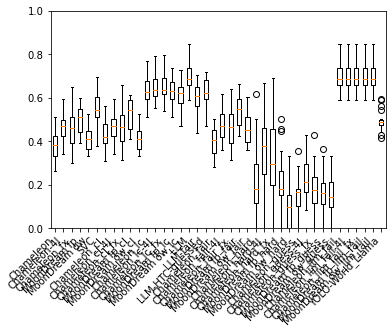

cvm_mean_time_cham = 41.452013970095365
cvm_mean_time_cham_fp = 41.452013970095365
cvm_mean_time_md_fp = 23.509972103689528
cvm_mean_time_md_ow = 11.989318196371952
svc_mean_time = 0.001060590821654303


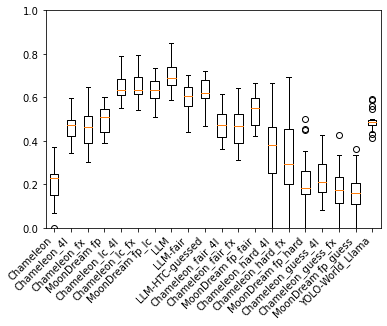

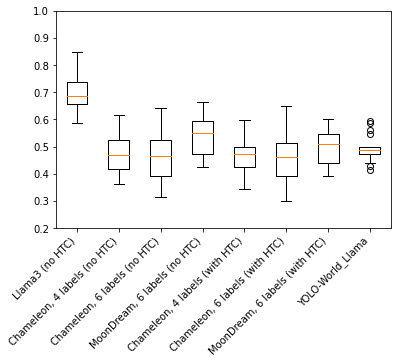

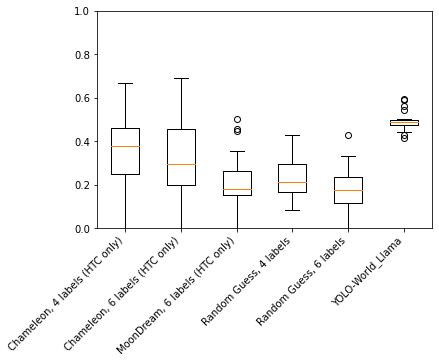

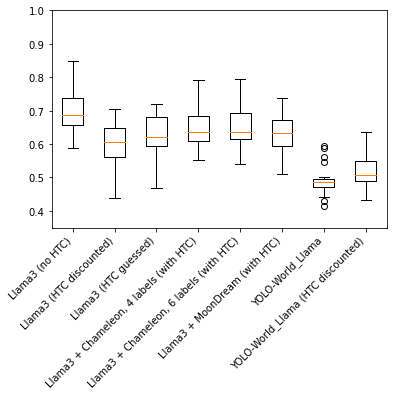

Mean vals: 0.6961394639527206 ## 0.6046702533246948 ## 0.626916249776397 ## 0.6515135429257296 ## 0.6515567618320259 ## 0.6338887563722139


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from statistics import mean

##
# This function will create a box plot for a hybridized data set (HYBRID_AT_12 or HYBRID_AT_18)
##
def testRoomClassifierAccuracy(llm_type):
    (llm_accuracies, svc_accuracies, cvm_accuracies, llm_mean_time, svc_mean_time, cvm_mean_time) = process_scene_files(llm_type)
    # should be 3 volumes -- one for LLM and one for SVC and one for CVM for accuracies compared to ground truth.
    number_of_dataset_volumes = 3

    # How many rooms were classified
    number_of_tests_per_dataset_volume = len(llm_accuracies)

    # We'll create an empty Numpy array and put the our SVC accuracies into there.
    dataset_test_results = np.zeros(shape=(number_of_dataset_volumes, number_of_tests_per_dataset_volume))
    #print(dataset_test_results.shape)

    dataset_test_results[0] = llm_accuracies
    dataset_test_results[1] = svc_accuracies
    dataset_test_results[2] = cvm_accuracies

    # transpose it because I imagined it differently to how matplotlib needs the data
    dataset_test_results = np.transpose(dataset_test_results)
    #print(dataset_test_results)
    fig, ax = plt.subplots()
    ax.axes.get_xaxis().set_visible(False)
    #ax7.set_title("Variance while " + operation + " " + gesture + " gesture")
    #if (model_type == ModelType.HYBRID_AT_12):
    #    ax.set_title("Sunrgbd - Hybridized with AI2-THOR data")
    #elif (model_type == ModelType.HYBRID_AT_18):
    #    ax.set_title("Scannet - Hybridized with AI2-THOR data")
    ax.boxplot(dataset_test_results)
    plt.ylim(0.3, 1.0)
    plt.show()

#testRoomClassifierAccuracy("gemma")
#testRoomClassifierAccuracy("mistral")
#testRoomClassifierAccuracy("LLAMA")

##
# This function will create a box plot for a hybridized data set (HYBRID_AT_12 or HYBRID_AT_18)
##
def testAllRoomClassifiersAccuracy():
    (llm_accuracies_fair, svc_accuracies, cvm_accuracies_cham, llm_mean_time, svc_mean_time, cvm_mean_time_cham, storages_and_offices_cham) = process_scene_files("CHAMELEON")
    (_, _, cvm_accuracies_cham_fp, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp, storages_and_offices_cham_fp) = process_scene_files("CHAMELEON_full_prompt")
    (_, _, cvm_accuracies_cham_4l, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp, storages_and_offices_cham_fp) = process_scene_files("CHAMELEON_4labels")
    (_, _, cvm_accuracies_cham_fx, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp, storages_and_offices_cham_fp) = process_scene_files("CHAMELEON_fixed")
    (_, _, cvm_accuracies_md_fp, llm_mean_time, svc_mean_time, cvm_mean_time_md_fp, storages_and_offices_md_fp) = process_scene_files("MOONDREAM_full_prompt")
    (_, _, cvm_accuracies_md_ow, llm_mean_time, svc_mean_time, cvm_mean_time_md_ow, storages_and_offices_md_ow) = process_scene_files("MOONDREAM_one_word")

    (_, _, cvm_accuracies_cham_fp_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp, storages_and_offices_cham_fp) = process_scene_files("CHAMELEON_full_prompt", ClassifierFusionType.LLM_THEN_CVM)
    (_, _, cvm_accuracies_cham_4l_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp, storages_and_offices_cham_fp) = process_scene_files("CHAMELEON_4labels", ClassifierFusionType.LLM_THEN_CVM)
    (_, _, cvm_accuracies_cham_fx_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp, storages_and_offices_cham_fp) = process_scene_files("CHAMELEON_fixed", ClassifierFusionType.LLM_THEN_CVM)
    (_, _, cvm_accuracies_md_fp_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_md_fp, storages_and_offices_md_fp) = process_scene_files("MOONDREAM_full_prompt", ClassifierFusionType.LLM_THEN_CVM)
    (_, _, cvm_accuracies_md_ow_llmtcvm, llm_mean_time, svc_mean_time, cvm_mean_time_md_ow, storages_and_offices_md_ow) = process_scene_files("MOONDREAM_one_word", ClassifierFusionType.LLM_THEN_CVM)

    (_, _, cvm_accuracies_cham_fp_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp, storages_and_offices_cham_fp) = process_scene_files("CHAMELEON_full_prompt", ClassifierFusionType.CVM_THEN_LLM)
    (_, _, cvm_accuracies_cham_4l_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp, storages_and_offices_cham_fp) = process_scene_files("CHAMELEON_4labels", ClassifierFusionType.CVM_THEN_LLM)
    (_, _, cvm_accuracies_cham_fx_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_cham_fp, storages_and_offices_cham_fp) = process_scene_files("CHAMELEON_fixed", ClassifierFusionType.CVM_THEN_LLM)
    (_, _, cvm_accuracies_md_fp_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_md_fp, storages_and_offices_md_fp) = process_scene_files("MOONDREAM_full_prompt", ClassifierFusionType.CVM_THEN_LLM)
    (_, _, cvm_accuracies_md_ow_cvmtllm, llm_mean_time, svc_mean_time, cvm_mean_time_md_ow, storages_and_offices_md_ow) = process_scene_files("MOONDREAM_one_word", ClassifierFusionType.CVM_THEN_LLM)
    (llm_accuracies, _, _, llm_mean_time, svc_mean_time, _, _) = process_scene_files("LLAMA")

    (_, _, cvm_accuracies_cham_fp_fair, _, _, _, _) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
    (_, _, cvm_accuracies_cham_4l_fair, _, _, _, _) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
    (_, _, cvm_accuracies_cham_fx_fair, _, _, _, _) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
    (_, _, cvm_accuracies_md_fp_fair, _, _, _, _) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
    (_, _, cvm_accuracies_md_ow_fair, _, _, _, _) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)

    (_, _, cvm_accuracies_cham_fp_hard, _, _, _, _) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
    (_, _, cvm_accuracies_cham_4l_hard, _, _, _, _) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
    (_, _, cvm_accuracies_cham_fx_hard, _, _, _, _) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
    (_, _, cvm_accuracies_md_fp_hard, _, _, _, _) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)
    (_, _, cvm_accuracies_md_ow_hard, _, _, _, _) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_HARD_CASES_ONLY_CVM)

    (_, _, cvm_accuracies_cham_fp_guess, _, _, _, _) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
    (_, _, cvm_accuracies_cham_4l_guess, _, _, _, _) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
    (_, _, cvm_accuracies_cham_fx_guess, _, _, _, _) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
    (_, _, cvm_accuracies_md_fp_guess, _, _, _, _) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)
    (_, _, cvm_accuracies_md_ow_guess, _, _, _, _) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_ONLY_CVM)

    (_, _, cvm_accuracies_cham_fp_llm_fail, _, _, _, _) = process_scene_files("CHAMELEON_full_prompt", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
    (_, _, cvm_accuracies_cham_4l_llm_fail, _, _, _, _) = process_scene_files("CHAMELEON_4labels", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
    (_, _, cvm_accuracies_cham_fx_llm_fail, _, _, _, _) = process_scene_files("CHAMELEON_fixed", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
    (_, _, cvm_accuracies_md_fp_llm_fail, _, _, _, _) = process_scene_files("MOONDREAM_full_prompt", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
    (_, _, cvm_accuracies_md_ow_llm_fail, _, _, _, _) = process_scene_files("MOONDREAM_one_word", fusion_type = ClassifierFusionType.LLM_THEN_CVM, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)

    (llm_accuracies_htc_guessed, _, _, _, _, _, _) = process_scene_files("CHAMELEON", what_to_do_with_hard_scenes = HardClassBehaviour.GUESS_HARD_CASES_WHEN_LLM)
    
    # YOLO-World + Llama3
    (_, _, yolo_world_accuracies, _, _, _, _) = process_scene_files("yolo_LLAMA", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_CVM_WHAT_LLM_CANNOT)
    (_, _, yolo_world_accuracies_no_htc, _, _, _, _) = process_scene_files("yolo_LLAMA", fusion_type = ClassifierFusionType.NO_FUSION, what_to_do_with_hard_scenes = HardClassBehaviour.CLASSIFY_WITH_NEITHER)
    
    # should be two volumes -- one for LLM and one for SVC for accuracies compared to ground truth.
    #number_of_dataset_volumes = 11

    # How many rooms were classified
    #number_of_tests_per_dataset_volume = len(svc_accuracies)
    print(str(len(svc_accuracies)) + " " + str(len(cvm_accuracies_cham)) + " " + str(len(cvm_accuracies_cham_fp)) + " " + str(len(cvm_accuracies_md_fp)) + " " + str(len(cvm_accuracies_md_ow)))
    print(str(storages_and_offices_cham) + " " + str(storages_and_offices_cham))

    # We'll create an empty Numpy array and put the our SVC accuracies into there.
    #dataset_test_results = np.zeros(shape=(number_of_dataset_volumes, number_of_tests_per_dataset_volume))
    #print(dataset_test_results.shape)

#    dataset_test_results[0] = cvm_accuracies_cham
#    dataset_test_results[1] = cvm_accuracies_cham_fp
#    dataset_test_results[2] = cvm_accuracies_md_fp
#    dataset_test_results[3] = cvm_accuracies_md_ow
#    dataset_test_results[4] = svc_accuracies

    #dataset_test_results = [cvm_accuracies_cham, cvm_accuracies_cham_fp, cvm_accuracies_md_fp, cvm_accuracies_md_ow, svc_accuracies]
    dataset_test_results = [cvm_accuracies_cham_fp, cvm_accuracies_cham_4l, cvm_accuracies_cham_fx, cvm_accuracies_md_fp, cvm_accuracies_md_ow, 
                            svc_accuracies, 
                            cvm_accuracies_cham_fp_cvmtllm, cvm_accuracies_cham_4l_cvmtllm, cvm_accuracies_cham_fx_cvmtllm, cvm_accuracies_md_fp_cvmtllm, cvm_accuracies_md_ow_cvmtllm, 
                            cvm_accuracies_cham_fp_llmtcvm, cvm_accuracies_cham_4l_llmtcvm, cvm_accuracies_cham_fx_llmtcvm, cvm_accuracies_md_fp_llmtcvm, cvm_accuracies_md_ow_llmtcvm, 
                            llm_accuracies, 
                            llm_accuracies_fair, 
                            llm_accuracies_htc_guessed,
                            cvm_accuracies_cham_fp_fair, cvm_accuracies_cham_4l_fair, cvm_accuracies_cham_fx_fair, cvm_accuracies_md_fp_fair, cvm_accuracies_md_ow_fair, 
                            cvm_accuracies_cham_fp_hard, cvm_accuracies_cham_4l_hard, cvm_accuracies_cham_fx_hard, cvm_accuracies_md_fp_hard, cvm_accuracies_md_ow_hard, 
                            cvm_accuracies_cham_fp_guess, cvm_accuracies_cham_4l_guess, cvm_accuracies_cham_fx_guess, cvm_accuracies_md_fp_guess, cvm_accuracies_md_ow_guess, 
                            cvm_accuracies_cham_fp_llm_fail, cvm_accuracies_cham_4l_llm_fail, cvm_accuracies_cham_fx_llm_fail, cvm_accuracies_md_fp_llm_fail, cvm_accuracies_md_ow_llm_fail,
                            yolo_world_accuracies]

    # transpose it because I imagined it differently to how matplotlib needs the data
    dataset_test_results = np.transpose(dataset_test_results)
    #print(dataset_test_results)
    fig, ax = plt.subplots()
    ax.axes.get_xaxis().set_visible(False)
    #ax7.set_title("Variance while " + operation + " " + gesture + " gesture")
    #if (model_type == ModelType.HYBRID_AT_12):
    #    ax.set_title("Sunrgbd - Hybridized with AI2-THOR data")
    #elif (model_type == ModelType.HYBRID_AT_18):
    #    ax.set_title("Scannet - Hybridized with AI2-THOR data")
    #ax.boxplot(dataset_test_results, labels=['Chameleon', 'Chameleon fp', 'MoonDream fp', 'MoonDream ow', 'SVC'])
    labels=['Chameleon', 'Chameleon-4l', 'Chameleon_fx', 'MoonDream fp', 'MoonDream ow', 
            'SVC', 
            'Chameleon_cl', 'Chameleon_cl-4l', 'Chameleon_cl_fx', 'MoonDream fp_cl', 'MoonDream ow_cl', 
            'Chameleon_lc', 'Chameleon_lc-4l', 'Chameleon_lc_fx', 'MoonDream fp_lc', 'MoonDream ow_lc', 
            'LLM', 
            'LLM-fair', 
            'LLM-HTC-guessed',
            'Chameleon_fair', 'Chameleon_fair-4l', 'Chameleon_fair_fx', 'MoonDream fp_fair', 'MoonDream ow_fair', 
            'Chameleon_hard', 'Chameleon_hard-4l', 'Chameleon_hard_fx', 'MoonDream fp_hard', 'MoonDream ow_hard', 
            'Chameleon_guess', 'Chameleon_guess-4l', 'Chameleon_guess_fx', 'MoonDream fp_guess', 'MoonDream ow_guess', 
            'Chameleon_llm_fail', 'Chameleon_llm_fail-4l', 'Chameleon_llm_fail_fx', 'MoonDream fp_llm_fail', 'MoonDream ow_llm_fail',
            'YOLO-World_Llama']
    ax.boxplot(dataset_test_results, labels=labels)
    ax.axes.get_xaxis().set_visible(True)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    plt.ylim(0.0, 1.0)
    #plt.xticks([1, 2, 3], ['mon', 'tue', 'wed'])
    plt.show()

    print("cvm_mean_time_cham = " + str(cvm_mean_time_cham))
    print("cvm_mean_time_cham_fp = " + str(cvm_mean_time_cham_fp))
    print("cvm_mean_time_md_fp = " + str(cvm_mean_time_md_fp))
    print("cvm_mean_time_md_ow = " + str(cvm_mean_time_md_ow))
    print("svc_mean_time = " + str(svc_mean_time))


    # Interim chart
    dataset_test_results = [cvm_accuracies_cham, cvm_accuracies_cham_4l, cvm_accuracies_cham_fx, cvm_accuracies_md_fp, 
                            cvm_accuracies_cham_4l_llmtcvm, cvm_accuracies_cham_fx_llmtcvm, cvm_accuracies_md_fp_llmtcvm, 
                            llm_accuracies, 
                            llm_accuracies_fair, 
                            llm_accuracies_htc_guessed,
                            cvm_accuracies_cham_4l_fair, cvm_accuracies_cham_fx_fair, cvm_accuracies_md_fp_fair, 
                            cvm_accuracies_cham_4l_hard, cvm_accuracies_cham_fx_hard, cvm_accuracies_md_fp_hard, 
                            cvm_accuracies_cham_4l_guess, cvm_accuracies_cham_fx_guess, cvm_accuracies_md_fp_guess,
                            yolo_world_accuracies]

    # transpose it because I imagined it differently to how matplotlib needs the data
    dataset_test_results = np.transpose(dataset_test_results)
    #print(dataset_test_results)
    fig, ax = plt.subplots()
    ax.axes.get_xaxis().set_visible(False)
    #ax7.set_title("Variance while " + operation + " " + gesture + " gesture")
    #if (model_type == ModelType.HYBRID_AT_12):
    #    ax.set_title("Sunrgbd - Hybridized with AI2-THOR data")
    #elif (model_type == ModelType.HYBRID_AT_18):
    #    ax.set_title("Scannet - Hybridized with AI2-THOR data")
    #ax.boxplot(dataset_test_results, labels=['Chameleon', 'Chameleon fp', 'MoonDream fp', 'MoonDream ow', 'SVC'])
    labels=['Chameleon', 'Chameleon_4l', 'Chameleon_fx', 'MoonDream fp',
            'Chameleon_lc_4l', 'Chameleon_lc_fx', 'MoonDream fp_lc', 
            'LLM', 
            'LLM-fair', 
            'LLM-HTC-guessed',
            'Chameleon_fair_4l', 'Chameleon_fair_fx', 'MoonDream fp_fair', 
            'Chameleon_hard_4l', 'Chameleon_hard_fx', 'MoonDream fp_hard',  
            'Chameleon_guess_4l', 'Chameleon_guess_fx', 'MoonDream fp_guess',
            'YOLO-World_Llama']
    ax.boxplot(dataset_test_results, labels=labels)
    ax.axes.get_xaxis().set_visible(True)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    plt.ylim(0.0, 1.0)
    #plt.xticks([1, 2, 3], ['mon', 'tue', 'wed'])
    plt.show()

    
    # CVM and LLM comparison
    dataset_test_results = [llm_accuracies, cvm_accuracies_cham_4l_fair, cvm_accuracies_cham_fx_fair, cvm_accuracies_md_fp_fair, 
                            cvm_accuracies_cham_4l, cvm_accuracies_cham_fx, cvm_accuracies_md_fp,
                            yolo_world_accuracies]

    # transpose it because I imagined it differently to how matplotlib needs the data
    dataset_test_results = np.transpose(dataset_test_results)
    #print(dataset_test_results)
    fig, ax = plt.subplots()
    ax.axes.get_xaxis().set_visible(False)
    #ax7.set_title("Variance while " + operation + " " + gesture + " gesture")
    #if (model_type == ModelType.HYBRID_AT_12):
    #    ax.set_title("Sunrgbd - Hybridized with AI2-THOR data")
    #elif (model_type == ModelType.HYBRID_AT_18):
    #    ax.set_title("Scannet - Hybridized with AI2-THOR data")
    #ax.boxplot(dataset_test_results, labels=['Chameleon', 'Chameleon fp', 'MoonDream fp', 'MoonDream ow', 'SVC'])
    labels=['Llama3 (no HTC)', 'Chameleon, 4 labels (no HTC)', 'Chameleon, 6 labels (no HTC)', 'MoonDream, 6 labels (no HTC)', 
            'Chameleon, 4 labels (with HTC)', 'Chameleon, 6 labels (with HTC)', 'MoonDream, 6 labels (with HTC)',
            'YOLO-World_Llama']
    ax.boxplot(dataset_test_results, labels=labels)
    ax.axes.get_xaxis().set_visible(True)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    plt.ylim(0.2, 1.0)
    #plt.xticks([1, 2, 3], ['mon', 'tue', 'wed'])
    plt.show()



    # Hard part analysis
    dataset_test_results = [cvm_accuracies_cham_4l_hard, cvm_accuracies_cham_fx_hard, cvm_accuracies_md_fp_hard, 
                            cvm_accuracies_cham_4l_guess, cvm_accuracies_cham_fx_guess,
                            yolo_world_accuracies]

    # transpose it because I imagined it differently to how matplotlib needs the data
    dataset_test_results = np.transpose(dataset_test_results)
    #print(dataset_test_results)
    fig, ax = plt.subplots()
    ax.axes.get_xaxis().set_visible(False)
    #ax7.set_title("Variance while " + operation + " " + gesture + " gesture")
    #if (model_type == ModelType.HYBRID_AT_12):
    #    ax.set_title("Sunrgbd - Hybridized with AI2-THOR data")
    #elif (model_type == ModelType.HYBRID_AT_18):
    #    ax.set_title("Scannet - Hybridized with AI2-THOR data")
    #ax.boxplot(dataset_test_results, labels=['Chameleon', 'Chameleon fp', 'MoonDream fp', 'MoonDream ow', 'SVC'])
    labels=['Chameleon, 4 labels (HTC only)', 'Chameleon, 6 labels (HTC only)', 'MoonDream, 6 labels (HTC only)',  
            'Random Guess, 4 labels', 'Random Guess, 6 labels',
            'YOLO-World_Llama']
    ax.boxplot(dataset_test_results, labels=labels)
    ax.axes.get_xaxis().set_visible(True)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    plt.ylim(0.0, 1.0)
    #plt.xticks([1, 2, 3], ['mon', 'tue', 'wed'])
    plt.show()


    # Fused results
    dataset_test_results = [llm_accuracies, 
                            llm_accuracies_fair,
                            llm_accuracies_htc_guessed,
                            cvm_accuracies_cham_4l_llmtcvm, cvm_accuracies_cham_fx_llmtcvm, cvm_accuracies_md_fp_llmtcvm,
                            yolo_world_accuracies, yolo_world_accuracies_no_htc]

    # transpose it because I imagined it differently to how matplotlib needs the data
    dataset_test_results = np.transpose(dataset_test_results)
    #print(dataset_test_results)
    fig, ax = plt.subplots()
    ax.axes.get_xaxis().set_visible(False)
    #ax7.set_title("Variance while " + operation + " " + gesture + " gesture")
    #if (model_type == ModelType.HYBRID_AT_12):
    #    ax.set_title("Sunrgbd - Hybridized with AI2-THOR data")
    #elif (model_type == ModelType.HYBRID_AT_18):
    #    ax.set_title("Scannet - Hybridized with AI2-THOR data")
    #ax.boxplot(dataset_test_results, labels=['Chameleon', 'Chameleon fp', 'MoonDream fp', 'MoonDream ow', 'SVC'])
    labels=['Llama3 (no HTC)', 
            'Llama3 (HTC discounted)', 
            'Llama3 (HTC guessed)', 
            'Llama3 + Chameleon, 4 labels (with HTC)', 'Llama3 + Chameleon, 6 labels (with HTC)', 'Llama3 + MoonDream (with HTC)',
            'YOLO-World_Llama', 'YOLO-World_Llama (HTC discounted)']
    ax.boxplot(dataset_test_results, labels=labels)
    ax.axes.get_xaxis().set_visible(True)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    plt.ylim(0.35, 1.0)
    #plt.xticks([1, 2, 3], ['mon', 'tue', 'wed'])
    plt.show()

    print("Mean vals: " + str(mean(llm_accuracies)) + " ## " + str(mean(llm_accuracies_fair)) + " ## " + str(mean(llm_accuracies_htc_guessed)) + " ## " + str(mean(cvm_accuracies_cham_4l_llmtcvm)) + " ## " + str(mean(cvm_accuracies_cham_fx_llmtcvm)) + " ## " + str(mean(cvm_accuracies_md_fp_llmtcvm)))


testAllRoomClassifiersAccuracy()